Francesco Ceron 2158534

francesco.ceron.2@studenti.unipd.it


Department of Mathematics – Data Science
University of Padua

Academic Year: 2025–2026

Dataset: Fashion-MNIST dataset

https://www.kaggle.com/datasets/zalando-research/fashionmnist

Xiao et al., 2017

Library:
- NumPy  
  https://numpy.org/doc/

- Pandas  
  https://pandas.pydata.org/docs/

- Matplotlib  
  https://matplotlib.org/stable/

- PyTorch  
  https://pytorch.org/docs/stable/

- Scikit-learn  
  https://scikit-learn.org/stable/documentation.html

- SciPy  
  https://docs.scipy.org/doc/scipy/

- kagglehub  
  https://github.com/Kaggle/kagglehub

- tqdm
  https://tqdm.github.io/

In [ ]:
def get_dbn_library():
  files = ["DBN.py", "RBM.py"]
  repository_url = "https://raw.githubusercontent.com/flavio2018/Deep-Belief-Network-pytorch/master/"
  for file in files:
    ! wget -O {file} {repository_url}{file}

In [ ]:
%%capture
get_dbn_library()

In [ ]:
import math
import random
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import torch.nn as nn
import matplotlib.pyplot as plt
import sklearn.preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import scipy.cluster.hierarchy as hierarchy
import torchvision as tv
from DBN import DBN
import kagglehub
from tqdm.notebook import tqdm
SEED=42

In [ ]:
print(torch.cuda.is_available())
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)

True
cuda


# Dataset: Fashion-MNIST dataset


The dataset has 70,000 grayscale images and their spatial resolution is 28×28 pixels.

The class labels are: T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot.
the dataset is divided into training set with 60000 images while the test set contains 10,000 images.

Below, I normalized the values to the range [0, 1], and previously, they were in the range [0, 255].

It can be considered a balanced dataset beacuse we have approximately the same number of samples for each class.  

The images are grayscale, moreover the dataset has some difficult visual problems because items from the same class can look quite different, and items from different classes can look very similar. This is especially true for upper-body clothes, like shirts, pullovers, and coats.

In [ ]:
#Loading of the data
path = kagglehub.dataset_download("zalando-research/fashionmnist")
train_fm = pd.read_csv(f"{path}/fashion-mnist_train.csv")
test_fm= pd.read_csv(f"{path}/fashion-mnist_test.csv")

Using Colab cache for faster access to the 'fashionmnist' dataset.


In [ ]:
#devided the data
X_train = torch.tensor(train_fm.iloc[:, 1:].values, dtype=torch.float32 )
y_train = torch.tensor(train_fm.iloc[:, 0].values,  dtype=torch.long)
X_test  = torch.tensor(test_fm.iloc[:, 1:].values,   dtype=torch.float32)
y_test  = torch.tensor(test_fm.iloc[:, 0].values,    dtype=torch.long)
#normalizzation
X_train = X_train.view(-1, 1, 28, 28) / 255.0
X_test  = X_test.view(-1, 1, 28, 28) / 255.0
#we work on cuda, for this reason we must readdress
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_train = X_train.to(device)
X_test  = X_test.to(device)
y_train = y_train.to(device)
y_test  = y_test.to(device)

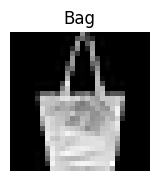

In [ ]:
fm_classes = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

def visualize_fashion(data, targets, n=5, class_name=None):
    if class_name is not None:
        class_idx = fm_classes.index(class_name)
        idxs = [i for i, t in enumerate(targets) if t == class_idx][:n]
    else:
        idxs = range(n)

    plt.figure(figsize=(1.8 * n, 2))
    for i, j in enumerate(idxs):
        plt.subplot(1, n, i + 1)

        img = data[j].detach().cpu().squeeze()
        plt.imshow(img, cmap="gray")

        plt.title(fm_classes[int(targets[j])])
        plt.axis("off")

    plt.show()
visualize_fashion(X_train, y_train, n=1, class_name="Bag")


In [ ]:
X_all = X_train.view(len(X_train), -1).float()
print(X_all.shape)

torch.Size([60000, 784])


# Unsupervised split

In [ ]:
N = len(X_all)
idx = torch.randperm(N, device=device)
split = int(0.85 * N)
tr_idx, val_idx = idx[:split], idx[split:]

X_unsup_tr  = X_all[tr_idx]
X_unsup_val = X_all[val_idx]
y_dummy_tr  = torch.zeros(len(X_unsup_tr),  dtype=torch.long, device=device)
y_dummy_val = torch.zeros(len(X_unsup_val), dtype=torch.long, device=device)

In [ ]:
print(X_unsup_tr[0,0:8])
print(X_unsup_val[0,0:8])
print(y_dummy_tr[0:8])
print(y_dummy_val[0:8])

tensor([0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0')
tensor([0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0')
tensor([0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')
tensor([0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')


In [ ]:
def fun_mse(dbn, X):
    dbn.eval()
    with torch.no_grad():
        X = X.to(next(dbn.parameters()).device)
        X_rec, _ = dbn.reconstruct(X)
        return F.mse_loss(X_rec, X).item()
X_train_flat = X_train.view(-1, 28*28)
X_test_flat  = X_test.view(-1, 28*28)

X_train_screen, X_unsupervise, y_dummy_screen, _ = train_test_split(
    X_train_flat, y_train, test_size=0.1, random_state=42
)

TUNING

In [ ]:

'''param_grid_screen = {
    "hidden_units": [[400, 500],[400, 800],[400, 600, 800]],
    "learning_rate": [0.01, 0.03, 0.05],
    "weight_decay": [0.0, 1e-4],
    "k": [1],
    "epochs": [10],
}
n_screen = 30000 #reduced portion of the training data
idx = torch.randperm(len(X_unsup_tr))[:n_screen]
X_screen = X_unsup_tr[idx]
y_dummy_screen = y_dummy_tr[idx]

screen_res = []

for cfg in ParameterGrid(param_grid_screen):
    dbn = DBN(
        visible_units=784,
        hidden_units=cfg["hidden_units"],
        k=cfg["k"],
        learning_rate=cfg["learning_rate"],
        learning_rate_decay=False,
        initial_momentum=0.5,
        final_momentum=0.95,
        weight_decay=cfg["weight_decay"],
        xavier_init=False,
        increase_to_cd_k=False,
        use_gpu=torch.cuda.is_available()
    )
    dbn.train_static(
        X_screen,
        y_dummy_screen,
        num_epochs=cfg["epochs"],
        batch_size=125
    )
    val_mse = fun_mse(dbn, X_unsup_val)
    screen_res.append({
        **cfg,
        "val_recon_mse": val_mse
    })
'''

'param_grid_screen = {\n    "hidden_units": [[400, 500],[400, 800],[400, 600, 800]],\n    "learning_rate": [0.01, 0.03, 0.05],\n    "weight_decay": [0.0, 1e-4],\n    "k": [1],\n    "epochs": [10],\n}\nn_screen = 30000 #reduced portion of the training data\nidx = torch.randperm(len(X_unsup_tr))[:n_screen]\nX_screen = X_unsup_tr[idx]\ny_dummy_screen = y_dummy_tr[idx]\n\nscreen_res = []\n\nfor cfg in ParameterGrid(param_grid_screen):\n    dbn = DBN(\n        visible_units=784,\n        hidden_units=cfg["hidden_units"],\n        k=cfg["k"],\n        learning_rate=cfg["learning_rate"],\n        learning_rate_decay=False,\n        initial_momentum=0.5,\n        final_momentum=0.95,\n        weight_decay=cfg["weight_decay"],\n        xavier_init=False,\n        increase_to_cd_k=False,\n        use_gpu=torch.cuda.is_available()\n    )\n    dbn.train_static(\n        X_screen,\n        y_dummy_screen,\n        num_epochs=cfg["epochs"],\n        batch_size=125\n    )\n    val_mse = fun_mse(dbn, 

In [ ]:
'''
df_screen = (
    pd.DataFrame(screen_res)
      .sort_values("val_recon_mse")
      .reset_index(drop=True)
)
df_screen.head(5)'''

'\ndf_screen = (\n    pd.DataFrame(screen_res)\n      .sort_values("val_recon_mse")\n      .reset_index(drop=True)\n)\ndf_screen.head(5)'

In [ ]:
#REFINE

'''refine_grid = {"hidden_units": [[400, 500],[400, 800]],
    "learning_rate": [0.03,0.05],
    "k": [1,2],
    "weight_decay": [0.0, 1e-4],
    "epochs": [50],
}
refine_res = []

for cfg in ParameterGrid(refine_grid):
    dbn = DBN(
        visible_units=784,
        hidden_units=cfg["hidden_units"],
        k=cfg["k"],
        learning_rate=cfg["learning_rate"],
        learning_rate_decay=False,
        initial_momentum=0.5,
        final_momentum=0.95,
        weight_decay=cfg["weight_decay"],
        xavier_init=False,
        increase_to_cd_k=False,
        use_gpu=torch.cuda.is_available()
    )
    dbn.train_static(
        X_unsup_tr,
        y_dummy_tr,
        num_epochs=cfg["epochs"],
        batch_size=125
    )
    val_mse = fun_mse(dbn, X_unsup_val)
    refine_res.append({
        **cfg,
        "val_recon_mse": val_mse
    })
'''

'refine_grid = {"hidden_units": [[400, 500],[400, 800]],\n    "learning_rate": [0.03,0.05],\n    "k": [1,2],\n    "weight_decay": [0.0, 1e-4],\n    "epochs": [50],\n}\nrefine_res = []\n\nfor cfg in ParameterGrid(refine_grid):\n    dbn = DBN(\n        visible_units=784,\n        hidden_units=cfg["hidden_units"],\n        k=cfg["k"],\n        learning_rate=cfg["learning_rate"],\n        learning_rate_decay=False,\n        initial_momentum=0.5,\n        final_momentum=0.95,\n        weight_decay=cfg["weight_decay"],\n        xavier_init=False,\n        increase_to_cd_k=False,\n        use_gpu=torch.cuda.is_available()\n    )\n    dbn.train_static(\n        X_unsup_tr,\n        y_dummy_tr,\n        num_epochs=cfg["epochs"],\n        batch_size=125\n    )\n    val_mse = fun_mse(dbn, X_unsup_val)\n    refine_res.append({\n        **cfg,\n        "val_recon_mse": val_mse\n    })\n'

In [ ]:
'''df_refine = (
    pd.DataFrame(refine_res)
      .sort_values("val_recon_mse")
      .reset_index(drop=True)
)
df_refine.head(3)'''

'df_refine = (\n    pd.DataFrame(refine_res)\n      .sort_values("val_recon_mse")\n      .reset_index(drop=True)\n)\ndf_refine.head(3)'

Above I performed a tuning phase, This is a preliminary phase for choosing the best hyperparameters to explore different Deep Belief Network configurations.

The code studies in particular the combinations of: number of hidden layers and number of hidden units, learning rate, weight decay, number of contrastive divergence steps.

After this first phase, there is a refinement phase to find the best overall configuration and training it for a larger number of epochs.

To avoid excessively long execution times during evaluation I commented all these phases.

In [ ]:
final_choice= {
    "epochs": 50,
    "batch_size": 125,
    "hidden_units": [400, 800],
    "learning_rate": 0.03,
    "k": 1,
    "weight_decay": 0.0
}

# DBN selection

The main model is a Deep Belief Network (DBN), it is composed of a stack of Restricted Boltzmann Machines (RBM), they are trained in a greedy and unsupervised way.
The visible layer is constituted by 784 units, corresponding to input images with a spatial resolution of 28×28 pixels.
The network includes two hidden layers, with 400 and 800 units, respectively, and they give the capacity to the model to progressively transform the information.

Every RBM is trained thanks to Contrastive Divergence with a single Gibbs sampling step. In this way there is a good trade-off between efficiency and quality. No regularization in the form of weight decay is applied.

The training of the DBN is done for 50 epochs, with a batch size of 125, using the whole training set. The learning rate is fixed to 0.03.

Even if the Fashion-MNIST dataset provides class labels, the network is trained in a completely unsupervised way: the labels are not used during learning and fake labels are given only to satisfy the training function interface.

In [ ]:
dbn_fm = DBN(
    visible_units=28*28,
    hidden_units=[400, 800],
    k=1,
    learning_rate=0.03,
    learning_rate_decay=False,
    initial_momentum=0.5,
    final_momentum=0.95,
    weight_decay=0.0,
    xavier_init=False,
    increase_to_cd_k=False,
    use_gpu=torch.cuda.is_available()
)
y_dummy_all = torch.zeros(
    len(X_all),
    dtype=torch.long,
    device=device
)

dbn_fm.train_static(
    X_all,
    y_dummy_all,
    num_epochs=50,
    batch_size=125
)




--------------------
Training RBM layer 1
|Epoch |avg_rec_err |std_rec_err  |mean_grad |std_grad  |
|10    |1.9508     |0.0793       |144.7594   |3.0980     |
|20    |1.7672     |0.0743       |129.7082   |2.4251     |
|30    |1.7086     |0.0742       |124.0400   |2.8311     |
|40    |1.6733     |0.0737       |119.4908   |2.5658     |
|50    |1.6503     |0.0716       |117.5116   |2.1137     |
--------------------
Training RBM layer 2
|Epoch |avg_rec_err |std_rec_err  |mean_grad |std_grad  |
|10    |1.6251     |0.0468       |96.8060   |2.2129     |
|20    |1.3853     |0.0409       |81.5366   |1.5896     |
|30    |1.3154     |0.0385       |76.4832   |1.3127     |
|40    |1.2781     |0.0370       |73.5261   |1.1459     |
|50    |1.2565     |0.0375       |71.7225   |1.4304     |


# VISUALIZATION OF RECEPTIVE FIELD

To analyze internal representations, receptive fields of hidden units are used. In the RBM with visual input, every neuron of the hidden layer can be interpreted as a filter, and this filter responds to specific configurations of pixels of the input image.

The get_weights function takes the weight matrix of the selected RBM, corresponding to the connections between the visible layer and the hidden layer.
Each column of the weight matrix can be reshaped into 28×28 and displayed as an image, representing the visual pattern that the neuron is most sensitive to.

Moreover, to enhance the visualization of the weights, two post-processing operations are applied:
1. Thresholding: the goal is to set to zero the weights with an absolute value smaller than a fixed threshold, reducing noise and highlighting the most important connections.
2. Min-Max normalization: rescales the weight values in the range [0,1], making the different receptive fields comparable.

The plot_layer_receptive_fields function displays a subset of hidden units in a regular grid.

In [ ]:
def get_weights(dbn, layer):
    return dbn.rbm_layers[layer].W.detach().cpu().numpy()

def apply_threshold(weights, threshold=0.0):
    return weights * (np.abs(weights) > threshold)

def apply_min_max_scaler(weights):
    shape = weights.shape
    scaler = sklearn.preprocessing.MinMaxScaler()
    weights = scaler.fit_transform(weights.reshape(-1, 1))
    return weights.reshape(shape)

def plot_layer_receptive_fields(weights, title="", n_plots=100):
    n = int(math.sqrt(n_plots))
    fig, axes = plt.subplots(n, n, figsize=(10, 10))
    fig.suptitle(title)

    for i in range(n_plots):
        r, c = i % n, i // n
        axes[r, c].imshow(weights[i].reshape(28, 28), cmap="gray")
        axes[r, c].axis("off")

    plt.tight_layout()
    plt.show()

# Visualization of Learned Receptive Fields

FIRST LAYER RECEPTIVE FIELDS

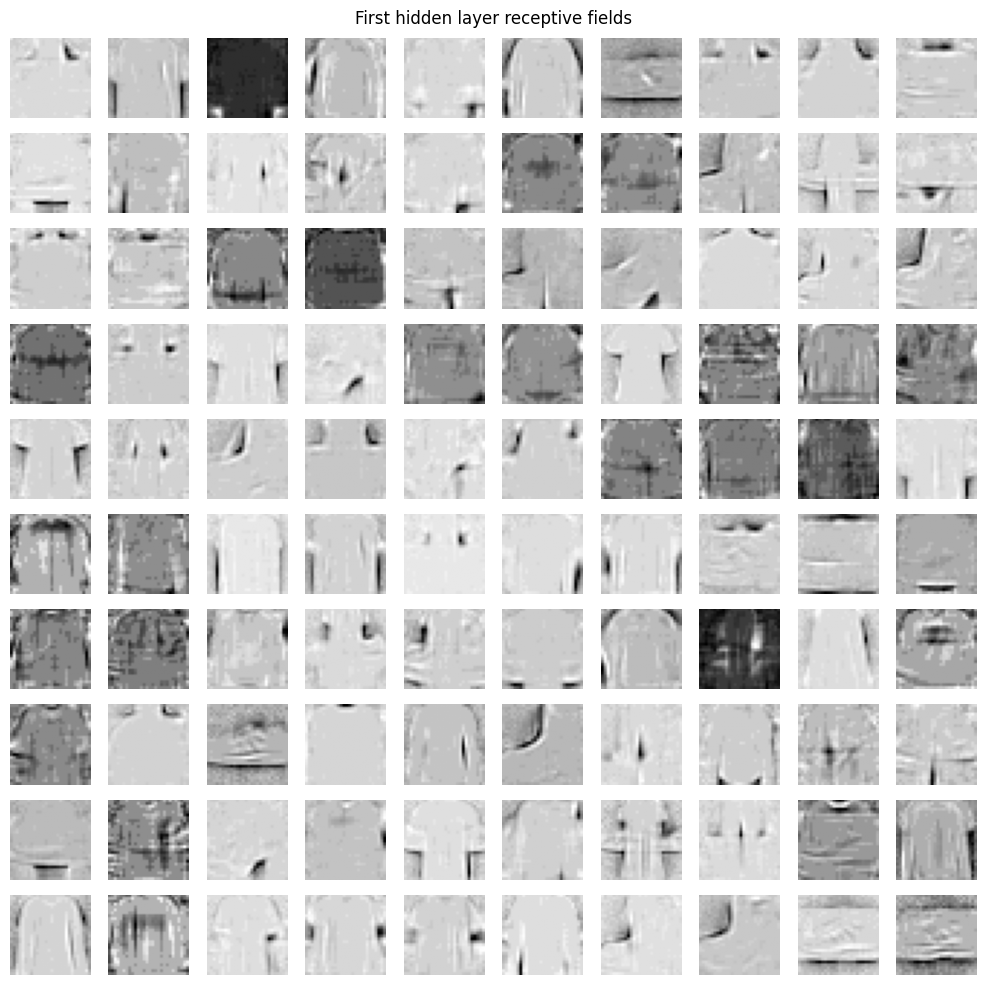

In [ ]:
W1 = get_weights(dbn_fm, layer=0)
W1 = apply_threshold(W1, threshold=0.1)
W1 = apply_min_max_scaler(W1)

plot_layer_receptive_fields(
    W1.T,
    title="First hidden layer receptive fields"
)

The first-layer receptive fields show mainly local structures with low-level features, such as edges, partial contours and variations in intensity.
This pattern reflect the role of the first hierarchical level, where it transforms the raw pixels in basic visual features. In some cases we observe parts of objects, but the representation remains local and fragmented.


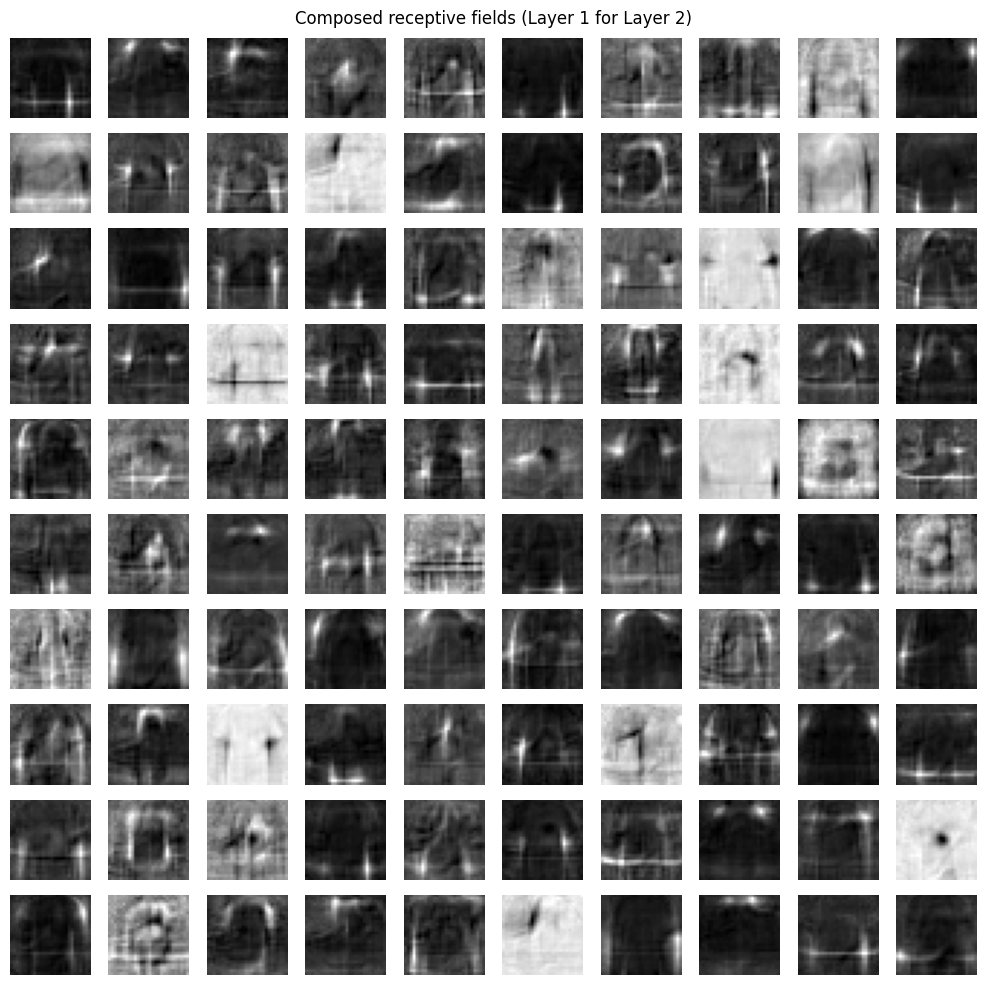

In [ ]:
W2 = get_weights(dbn_fm, layer=1)          # (400, 800)

W1 = apply_threshold(W1, 0.1)
W2 = apply_threshold(W2, 0.1)

W_composed = W1 @ W2                       # (784, 800)
W_composed = apply_threshold(W_composed, 0.1)
W_composed = apply_min_max_scaler(W_composed)

plot_layer_receptive_fields(
    W_composed.T,
    title="Composed receptive fields (Layer 1 for Layer 2)"
)

The second-layer receptive fields are more global and more structured than the first level. The units have more information from more elementary features, and provide more abstract representations. This behavior is coherent with the process of hierarchical abstraction, where the representation become gradually more complex and conceptual.


# HIERARCHICAL CLUSTERING

In [ ]:
def get_kth_layer_repr(dbn,X,k,device):
  v = X.reshape(X.shape[0],-1).float().to(device)
  for layer in range(k):
    _,v=dbn.rbm_layers[layer].to_hidden(v)
  hidden_repr,_ = dbn.rbm_layers[k].to_hidden(v)
  return hidden_repr

def get_mask(label,targets):
  return (targets.cpu().numpy()==label)

def get_label_to_mean_hidden_repr(hidden_repr,targets,n_classes=26):
  hidden_np = hidden_repr.cpu().numpy()
  label_to_mean = {}
  for label in range(n_classes):
        mask = get_mask(label, targets)
        label_to_mean[label] = hidden_np[mask].mean(axis=0)
  return label_to_mean

def get_hidden_repr_matrix(hidden_repr, targets, n_classes=10):
    label_to_mean = get_label_to_mean_hidden_repr(hidden_repr, targets, n_classes)
    return np.stack([label_to_mean[label] for label in range(n_classes)],axis=0)
def get_hidden_representation(dbn, X, layer, device):
    v = X.view(X.shape[0], -1).float().to(device)
    for i in range(layer + 1):
        _, v = dbn.rbm_layers[i].to_hidden(v)
    return v

hidden_repr_1 = get_hidden_representation(dbn_fm, X_train_screen, layer=0, device=device)
hidden_repr_2 = get_hidden_representation(dbn_fm, X_train_screen, layer=1, device=device)

print("Hidden layer 1 shape:", hidden_repr_1.shape)
print("Hidden layer 2 shape:", hidden_repr_2.shape)



Hidden layer 1 shape: torch.Size([54000, 400])
Hidden layer 2 shape: torch.Size([54000, 800])


In [ ]:
def plot_dendrogram(mean_repr_matrix, labels, title=" "):
    fig, ax = plt.subplots(figsize=(10, 5))
    linkage = hierarchy.linkage(mean_repr_matrix,method="complete")
    hierarchy.dendrogram(
        linkage,
        labels=labels,
        leaf_rotation=90
        )

    ax.set_title(title)
    ax.set_ylabel("Distance")
    plt.tight_layout()
    plt.show()


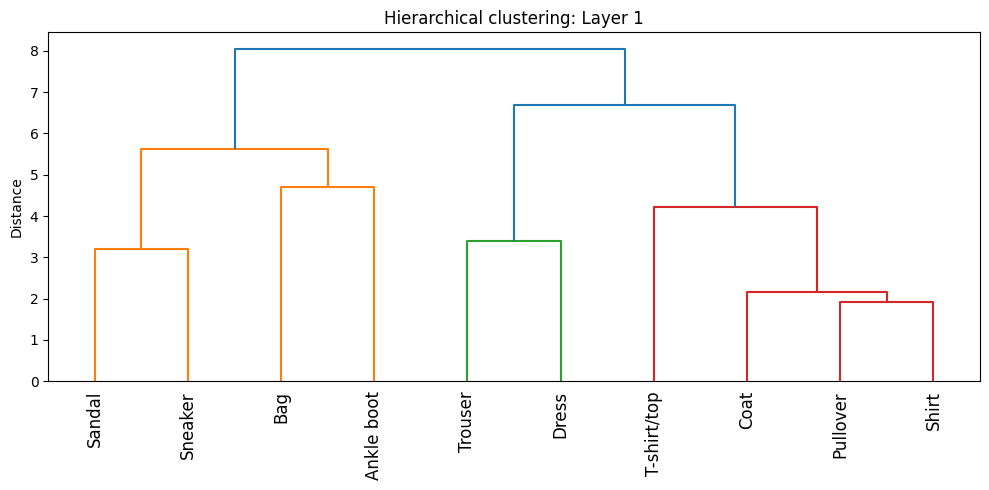

In [ ]:
h1 = get_kth_layer_repr(dbn_fm, X_train, k=0, device=device)

mean_h1 = get_hidden_repr_matrix(
    h1,
    y_train,
    n_classes=10
)

plot_dendrogram(
    mean_h1,
    labels=fm_classes, # to give the name
    title="Hierarchical clustering: Layer 1"
)


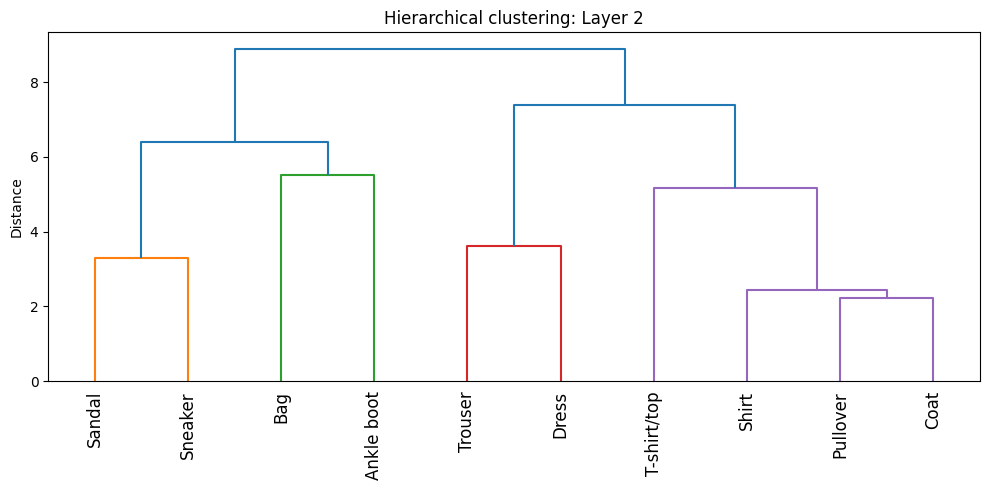

In [ ]:
h2 = get_kth_layer_repr(dbn_fm, X_train, k=1, device=device)

mean_h2 = get_hidden_repr_matrix(
    h2,
    y_train,
    n_classes=10
)

plot_dendrogram(
    mean_h2,
    labels=fm_classes, # to give the name
    title="Hierarchical clustering: Layer 2"
)


# Analysis of the dendrogram

Hierarchical clustering: Layer 1

In the first layer the corresponding dendrogram shows an initial organization of the classes, it is driven by low-level visual similarities. Categories such as Sandal and Sneaker tend to cluster together, like Pullover, Shirt and Coat.

Class separation remains partial, and they are not completely disentangled.

Hierarchical clustering: Layer 2

In the second hidden layer, the clstering appears more coherent and semantically interpretable.

The classes are grouped more consistently according to functional categories, suggesting that the second level captures more abstract and global visual structures.
This result indicates an improvement in class separability and supports the hypothesis that network depth favours the emergence of more disentangled representations.


# Linear read out


I analyze decodability with a linear read-out to evaluate the quality of the representations learned by the DBN.

Hidden representations taken from different layers of the network are used as input features for the linear classifier.

This type of approach allows us to assess how much the class-relevant information is linearly accessible at every level of the hierarchy, and without introducing additional non-linear transformations.

In [ ]:
#linear read-out
class LinearModel(torch.nn.Module):
    def __init__(self, layer_size, n_classes=10):
        super().__init__()
        self.linear = torch.nn.Linear(layer_size, n_classes)

    def forward(self, x):
        return self.linear(x)


In [ ]:
linear_models = [
    LinearModel(400).to(device),
    LinearModel(800).to(device)
]

linear1 = linear_models[0]
linear2 = linear_models[1]



The Linear classifiers are trained on top of the hidden representations taken from the first and second hidden layers. A supervised training split is used, and the optimization is done with stochastic gradient descent and cross-entropy loss.

In all these cases, the training loss decreases during the first epochs, and then stabilizes, and eventually converges for the linear models. The final loss values are similar for all layers, so both hidden layers contain a large amount of class information that a linear decoder can use.


In [ ]:
X_train_flat = X_train.view(-1, 28*28)

X_train_screen, X_val_screen, y_train_screen, y_val_screen = train_test_split(
    X_train_flat.cpu(),
    y_train.cpu(),
    test_size=0.1,
    random_state=42,
    stratify=y_train.cpu()
)


In [ ]:
X_train_screen = X_train_screen.to(device)
X_val_screen   = X_val_screen.to(device)
y_train_screen = y_train_screen.to(device)
y_val_screen   = y_val_screen.to(device)

In [ ]:
def train_linear(linear, features, targets, epochs=1000, lr=0.05):
    linear.train()
    optimizer = torch.optim.SGD(linear.parameters(), lr=lr)
    loss_fn = torch.nn.CrossEntropyLoss()

    for epoch in range(epochs):
        optimizer.zero_grad()
        logits = linear(features)
        loss = loss_fn(logits, targets)
        loss.backward()
        optimizer.step()

        if epoch % 100 == 0:
            print(f"epoch {epoch+1:4d}/{epochs}, loss = {loss.item():.4f}")


In [ ]:
rep='================================================================================================='
hidden_repr_1_train = get_hidden_representation(
dbn_fm, X_train_screen, layer=0, device=device
)
hidden_repr_2_train = get_hidden_representation(
    dbn_fm, X_train_screen, layer=1, device=device
)
print(rep)
train_linear(linear1, hidden_repr_1_train, y_train_screen)
print(rep)
train_linear(linear2, hidden_repr_2_train, y_train_screen)



epoch    1/1000, loss = 2.3898
epoch  101/1000, loss = 0.8347
epoch  201/1000, loss = 0.6892
epoch  301/1000, loss = 0.6285
epoch  401/1000, loss = 0.5926
epoch  501/1000, loss = 0.5680
epoch  601/1000, loss = 0.5498
epoch  701/1000, loss = 0.5356
epoch  801/1000, loss = 0.5242
epoch  901/1000, loss = 0.5147
epoch    1/1000, loss = 2.2968
epoch  101/1000, loss = 0.7792
epoch  201/1000, loss = 0.6643
epoch  301/1000, loss = 0.6146
epoch  401/1000, loss = 0.5848
epoch  501/1000, loss = 0.5644
epoch  601/1000, loss = 0.5493
epoch  701/1000, loss = 0.5376
epoch  801/1000, loss = 0.5281
epoch  901/1000, loss = 0.5203


# Compute the accuracy

In [ ]:
X_test_flat = X_test.view(X_test.shape[0], -1)
hidden_repr_1_test = get_hidden_representation(dbn_fm, X_test_flat, 0, device)
hidden_repr_2_test = get_hidden_representation(dbn_fm, X_test_flat, 1, device)


In [ ]:
def compute_accuracy(predictions, targets):
    preds = predictions.argmax(dim=1)
    acc = (preds == targets).float().mean()
    return acc.item()


In [ ]:
acc1 = compute_accuracy(linear1(hidden_repr_1_test), y_test)
acc2 = compute_accuracy(linear2(hidden_repr_2_test), y_test)
print(rep)
print("Layer 1 accuracy:", acc1)
print(rep)
print("Layer 2 accuracy:", acc2)
print(rep)


Layer 1 accuracy: 0.8210999965667725
Layer 2 accuracy: 0.808899998664856


Using linear read-outs trained on two hidden layers, I obtained the following accuracies:
1. Hidden layer 1: 0.82
2. Hidden layer 2: 0.81

The results show that both layers support accurate linear classification. The first hidden layer performs slightly better in terms of accuracy than the second.
This means that deeper layers get more abstract features, but they can also lose some fine-grained details that are useful for linear classification in a simple feedforward setup.

# Test for each layers

In [ ]:
def train_and_test_layer(layer, lr=1e-3, weight_decay=1e-5, epochs=400):
    X_train_flat = X_train.view(-1, 28*28) # Use global X_train
    X_test_flat  = X_test.view(-1, 28*28)  # Use global X_test

    H_train = get_hidden_representation(dbn_fm, X_train_flat, layer, device)
    H_test  = get_hidden_representation(dbn_fm, X_test_flat,  layer, device)

    model = LinearModel(H_train.shape[1]).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )
    loss_fn = nn.CrossEntropyLoss()

    for _ in range(epochs):
        optimizer.zero_grad()
        loss = loss_fn(model(H_train), y_train)
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        preds = model(H_test).argmax(dim=1)
        acc = (preds == y_test).float().mean().item()

    return acc

In [ ]:
acc_layer1 = train_and_test_layer(layer=0)
acc_layer2 = train_and_test_layer(layer=1)


print("Final linear read-out accuracies:")
print(rep)
print(f"Layer 1 accuracy: {acc_layer1:.4f}")
print(rep)
print(f"Layer 2 accuracy: {acc_layer2:.4f}")

Final linear read-out accuracies:
Layer 1 accuracy: 0.8279
Layer 2 accuracy: 0.8176


#Test on the pixel


To understand the quality of the representations learned by the DBN, we compute a linear classifier directly on raw pixel values. Every input image is flattened into a 784-dimensional vector, corresponding to the original pixels.

The linear model is then trained on the pixel-based rappresenations and it uses the same training procedure used for the linear read-outs applied to the hidden layers of the DBN. Classification performance is checked on the test set by calculating the accuracy from the model predictions.

This pixel-based linear read-out is used as a reference to compare with deeper DBN representations. As expected, the accuracy obtained from raw pixels is lower than that from hidden layers, showing that unsupervised hierarchical learning makes features more linearly separable and easier to use.


In [ ]:
X_pix_tr = X_train.view(X_train.shape[0], -1)
X_pix_te = X_test.view(X_test.shape[0], -1)

print(X_pix_tr.shape)
print(X_pix_te.shape)

pixel_linear = LinearModel(784).to(device)

train_linear(pixel_linear, X_pix_tr, y_train)
logits_pix = pixel_linear(X_pix_te)
pix_acc = compute_accuracy(logits_pix, y_test)

print(f"Pixels accuracy: {pix_acc:.3f}")


torch.Size([60000, 784])
torch.Size([10000, 784])
epoch    1/1000, loss = 2.3094
epoch  101/1000, loss = 0.8367
epoch  201/1000, loss = 0.7150
epoch  301/1000, loss = 0.6578
epoch  401/1000, loss = 0.6224
epoch  501/1000, loss = 0.5976
epoch  601/1000, loss = 0.5790
epoch  701/1000, loss = 0.5643
epoch  801/1000, loss = 0.5524
epoch  901/1000, loss = 0.5424
Pixels accuracy: 0.827


We can conclude this section, where the linear read-out analysis shows that unsupervised training of the DBN gives representations that are very useful for classification. The improvement in the pixel-based representations shows that the DBN effectively extracts meaningful visual features.

The absence of a strictly monotonic increase in accuracy through layers says that the deeper representations aren’t optimized for linear separability alone.

Moreover, the higher layers seem to show that they trade some details for more abstract and structured representations, infact, we can also see it in the  receptive field visualizations and hierarchical clustering results.

# I want to compute the confusion matrix

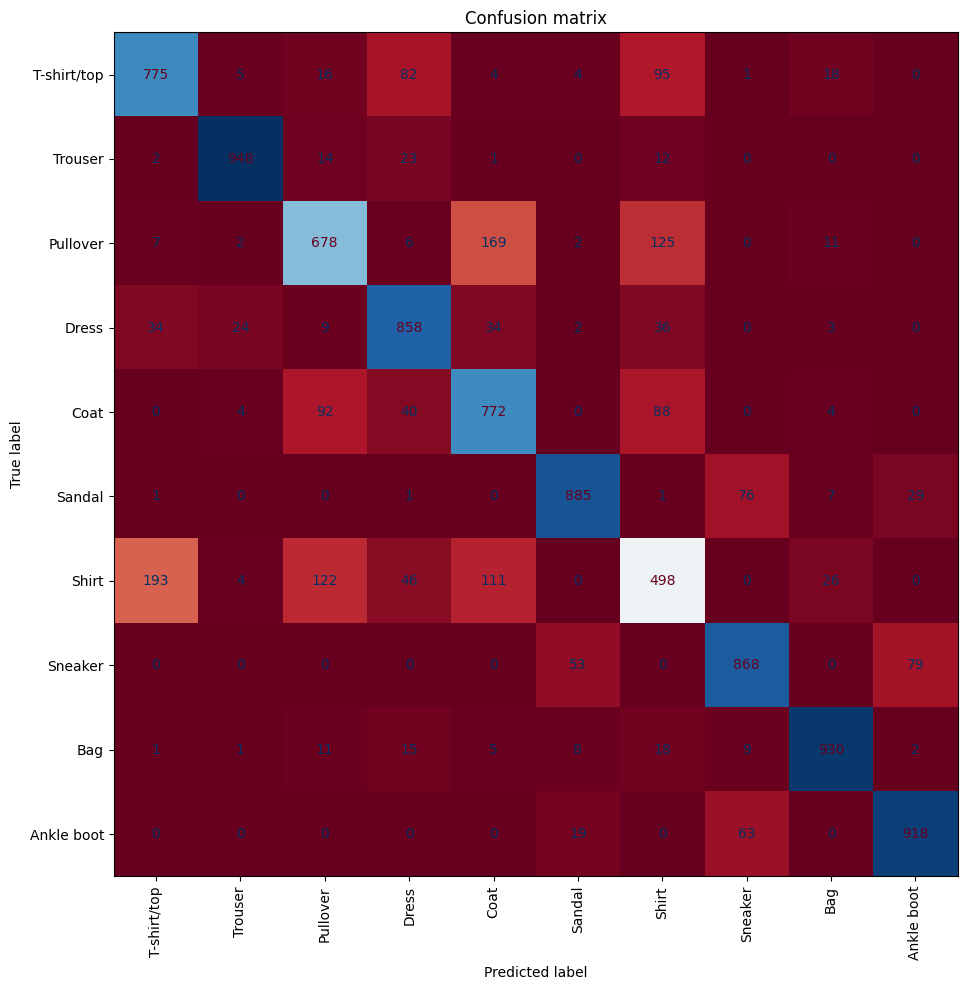

In [ ]:
hidden_2_test = get_hidden_representation(dbn_fm, X_test, layer=1, device=device)

with torch.no_grad():
    logits = linear2(hidden_2_test)
    preds = logits.argmax(dim=1)

cm = confusion_matrix(
    y_test.cpu().numpy(),
    preds.cpu().numpy(),
    labels=np.arange(10)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=fm_classes
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, cmap="RdBu", colorbar=False, values_format="d")
plt.title("Confusion matrix")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


The confusion matrix shows in detail the errors of misclassification of linear read-out applied to the representation of the second hidden layer. The matrix shows the evidence of a good global accuracy, with a strong concentration of the values along the main diagonal for the different classes, like: Trouser, Sneaker, Bag and Ankle Boot, they are well separated.

The most frequent errors are in 3 main categories, as these classes are very similar to one another Shirt, Pullover, Coat and T-shirt/top. For example, many Shirt are misclassified in T-shirt/top or Pullover, and this implies that some categories share some visive common features difficult to separate with a linear classifier.

The classes Sandal, Sneaker, and Ankle boot show a better separation. this suggests that the model captures global structural difference like shape and proportion.

The errors are coherent with the result of the hierarchical clustering.

# Create a Baseline

In [ ]:
class LogisticRegression(torch.nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.linear = torch.nn.Linear(784, n_classes)

    def forward(self, x):
        x = x.view(x.shape[0], -1)
        return self.linear(x)


In [ ]:
logreg = LogisticRegression().to(device)

optimizer = torch.optim.SGD(logreg.parameters(), lr=0.1)
loss_fn = torch.nn.CrossEntropyLoss()

for epoch in range(1050):
    optimizer.zero_grad()
    logits = logreg(X_train)
    loss = loss_fn(logits, y_train)
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"epoch {epoch}, loss = {loss.item():.4f}")


epoch 0, loss = 2.4198
epoch 50, loss = 0.8336
epoch 100, loss = 0.7127
epoch 150, loss = 0.6560
epoch 200, loss = 0.6210
epoch 250, loss = 0.5964
epoch 300, loss = 0.5780
epoch 350, loss = 0.5634
epoch 400, loss = 0.5516
epoch 450, loss = 0.5417
epoch 500, loss = 0.5332
epoch 550, loss = 0.5258
epoch 600, loss = 0.5194
epoch 650, loss = 0.5136
epoch 700, loss = 0.5085
epoch 750, loss = 0.5038
epoch 800, loss = 0.4996
epoch 850, loss = 0.4957
epoch 900, loss = 0.4921
epoch 950, loss = 0.4888
epoch 1000, loss = 0.4858


In [ ]:
logits_test = logreg(X_test)
logistic_reg_acc = compute_accuracy(logits_test, y_test)

print(f"Logistic Regression accuracy: {logistic_reg_acc:.3f}")

Logistic Regression accuracy: 0.842


As a baseline comparison, a logistic regression model is trained on the raw image pixels, without any preliminary representation learning.
The images are flattened into 784-dimensional vectors and used as input for a multiclass linear classifier.

The model is trained in a supervised manner using stochastic gradient descent and the cross-entropy loss function.
The training loss constantly decreasesand converges, showing that the optimization works correctly.

The accuracy obtained on the test set is 0.841, this indicates reasonable classification performance and this is possible directly in pixel space.
This baseline is using only to create a benchmark for the comparison.

# PSYCHOMETRIC CURVES

In [ ]:
def inject_noise(fashion_test, noise_level):
    noise_val = torch.randn_like(fashion_test) * noise_level
    noisy_data = fashion_test + noise_val
    noisy_data = torch.clamp(noisy_data, 0.0, 1.0)
    return noisy_data


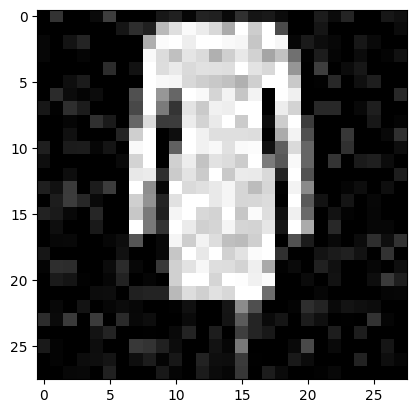

In [ ]:
noise_level = 0.1
fashion_test_with_noise = inject_noise(X_test, noise_level)
__ = plt.imshow(fashion_test_with_noise[4].reshape(28, 28).to("cpu"), cmap="gray")

In [ ]:
def get_accuracy_values_at_noise_level(noise_level):

  fashion_test_with_noise = inject_noise(X_test, noise_level)

  hidden_repr_1_noisy = get_hidden_representation(dbn_fm, fashion_test_with_noise, 0, device)
  hidden_repr_2_noisy = get_hidden_representation(dbn_fm, fashion_test_with_noise, 1, device)


  predictions_1_hidden_noisy = linear1(hidden_repr_1_noisy)  # here we use the previously-trained read-out classifiers
  predictions_2_hidden_noisy = linear2(hidden_repr_2_noisy)


  accuracy_1_hidden = compute_accuracy(predictions_1_hidden_noisy, y_test)
  accuracy_2_hidden = compute_accuracy(predictions_2_hidden_noisy, y_test)

  #baseline
  predictions_lg_noisy = logreg(fashion_test_with_noise)
  accuracy_lg = compute_accuracy(predictions_lg_noisy, y_test)

  return accuracy_1_hidden, accuracy_2_hidden, accuracy_lg

In [ ]:
acc = get_accuracy_values_at_noise_level(0.3);
print("Accuracy of H1 read-out: %.3f" % acc[0])
print("Accuracy of H2 read-out: %.3f" % acc[1])
print("Accuracy of Logistic: %.3f" % acc[2])


Accuracy of H1 read-out: 0.468
Accuracy of H2 read-out: 0.461
Accuracy of Logistic: 0.782


In [ ]:
def plot_noise_robustness_curves(noise_levels):
  accuracy_values_first_hidden = []
  accuracy_values_second_hidden = []
  accuracy_values_lgr = []

  for noise_level in noise_levels:
    acc = get_accuracy_values_at_noise_level(noise_level)
    accuracy_values_first_hidden.append(acc[0])
    accuracy_values_second_hidden.append(acc[1])
    accuracy_values_lgr.append(acc[2])

  fig, ax = plt.subplots()
  ax.plot(range(len(noise_levels)), accuracy_values_first_hidden)
  ax.plot(range(len(noise_levels)), accuracy_values_second_hidden)
  ax.plot(range(len(noise_levels)), accuracy_values_lgr)

  ax.set_title("Robustness to noise")
  ax.set_xlabel("Noise level (%)")
  ax.set_ylabel("Accuracy")
  plt.xticks(range(len(noise_levels)), [int(l*100) for l in noise_levels])
  plt.legend(["First hidden", "Second hidden", "Logistic regression"])

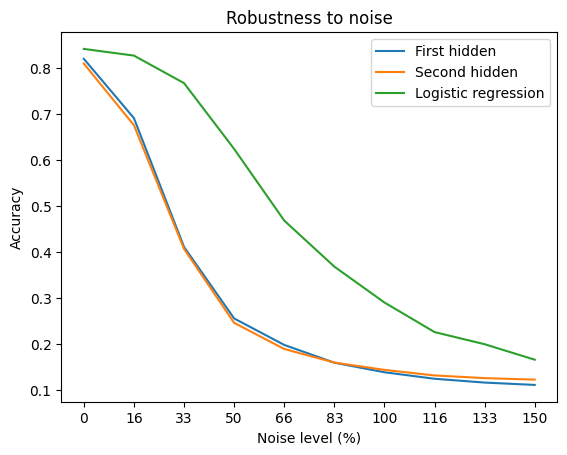

In [ ]:
noise_levels = np.linspace(0,1.5,10)
plot_noise_robustness_curves(noise_levels)

To evaluate the robustness of the representation, we add some Gaussian noise in the test images with increasing intensity, and measure the accuracy of the classifiers. The curves show that the accuracy decrease progressively when increasing the noise for each model.

The linear read-out based on the DBN result are more sensitive respect to the noise in the logistic regression on the pixel. In particular, at intermediate noise levels of noise is observed a fast decreasing of the performance, while the baseline remains at a higher accuracy.

This behavior suggests that the linear read out is more sensible respect to the baseline when it noise is introduced, probably because noise significantly alters the activation of hidden units.

# Adversial attack


In [ ]:
def fgsm_attack(image, epsilon, data_grad):
    sign_data_grad = data_grad.sign()
    return torch.clamp(image + epsilon * sign_data_grad, 0, 1)

In [ ]:
def normalize_fun(x, mean, std):
    return (x - mean) / (std + 1e-8)

@torch.no_grad()
def compute_norm_stats(x):
    return x.mean(dim=0, keepdim=True), x.std(dim=0, keepdim=True)

class DBNWithReadOut(torch.nn.Module):
    def __init__(self, dbn, readout, mean, std):
        super().__init__()
        self.dbn = dbn
        self.readout = readout
        self.mean = mean
        self.std = std
    def forward(self, x):
        v = x
        for rbm in self.dbn.rbm_layers:
            v = v.view(v.size(0), -1)
            v, _ = rbm.to_hidden(v)   # probabilities
        v = normalize_fun(v, self.mean, self.std)
        return self.readout(v)
# Computing normalization for H2 on the training split
with torch.no_grad():
    h2_train = get_hidden_representation(dbn_fm, X_train_screen, 1, device)
    h2_mean, h2_std = compute_norm_stats(h2_train)
    h2_mean, h2_std = h2_mean.to(device), h2_std.to(device)

In [ ]:
dbn_with_readout = DBNWithReadOut(dbn_fm, linear2, h2_mean, h2_std ).to(device).eval()
dbn_fm.eval()
linear2.eval()
logreg.eval()

LogisticRegression(
  (linear): Linear(in_features=784, out_features=10, bias=True)
)

It is a T-shirt/top


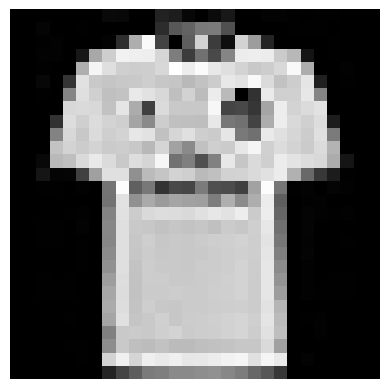

In [ ]:
test_sample_idx = 0
test_image = X_test[test_sample_idx].view(1, 784)

__ = plt.imshow(
    test_image.view(28, 28).detach().cpu(),
    cmap="gray"
)
plt.axis("off")
print(f'It is a {fm_classes[test_sample_idx]}')

In [ ]:
attacked_model_1 = dbn_with_readout
attacked_model_baseline = logreg

# dbn model

In [ ]:
test_image.requires_grad_()
model_outputs = attacked_model_1(test_image)
prediction = torch.argmax(model_outputs)
print(f"The prediction of the model for this clean sample is {prediction}, and it is a {fm_classes[prediction]}.")

The prediction of the model for this clean sample is 0, and it is a T-shirt/top.


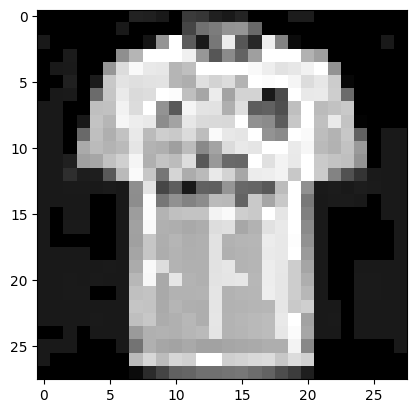

In [ ]:
epsilon = 0.1  # strenght of the attack
test_image_label = y_test[test_sample_idx].unsqueeze(0)
loss_value = torch.nn.functional.cross_entropy(model_outputs, test_image_label)
attacked_model_1.zero_grad()
loss_value.backward(retain_graph=True)
image_grad = test_image.grad.data

perturbed_image = fgsm_attack(test_image, epsilon, image_grad)
__ = plt.imshow(perturbed_image.reshape(28,28).to('cpu').detach().numpy(), cmap = 'gray')

In [ ]:
model_outputs = attacked_model_1(perturbed_image)
prediction_adv = model_outputs.argmax(dim=1)
print(f"The prediction of the model for the perturbed sample is {torch.argmax(model_outputs)}.")
print(f"It is a {fm_classes[torch.argmax(model_outputs)]}")


The prediction of the model for the perturbed sample is 0.
It is a T-shirt/top


# Baseline Logistic Regression

In [ ]:
test_image.requires_grad_()
model_outputs = attacked_model_baseline(test_image)
prediction = torch.argmax(model_outputs)
print(f"The prediction of the model for this clean sample is {prediction}, and it is a {fm_classes[prediction]}.")

The prediction of the model for this clean sample is 0, and it is a T-shirt/top.


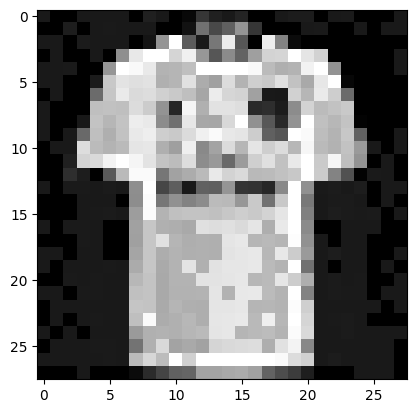

In [ ]:
epsilon = 0.1  # define strenght of the attack
test_image_label = y_test[test_sample_idx].unsqueeze(0)  # get ground truth label for that image
loss_value = torch.nn.functional.cross_entropy(model_outputs, test_image_label)  # get loss value
attacked_model_baseline.zero_grad()
loss_value.backward(retain_graph=True)
image_grad = test_image.grad.data  # get the gradient of the pixels w.r.t. the loss

perturbed_image = fgsm_attack(test_image, epsilon, image_grad)
__ = plt.imshow(perturbed_image.reshape(28,28).to('cpu').detach().numpy(), cmap = 'gray')

In [ ]:
model_outputs = attacked_model_baseline(perturbed_image)
prediction_adv = model_outputs.argmax(dim=1)
print(f"The prediction of the model for the perturbed sample is {torch.argmax(model_outputs)}.")
print(f"It is a {fm_classes[torch.argmax(model_outputs)]}")


The prediction of the model for the perturbed sample is 6.
It is a Shirt


In [ ]:
def fun_test_fgsm(model, X, y, epsilon, topdown_steps=0):
    correct = 0

    if topdown_steps > 0:
        rbm_pixel = dbn_fm.rbm_layers[0]


    for i in range(len(X)):
        x = X[i:i+1].to(device).detach().clone().requires_grad_(True)
        t = y[i:i+1].to(device)

        out = model(x)
        loss = F.cross_entropy(out, t)

        model.zero_grad(set_to_none=True)
        loss.backward()
        x_adv = fgsm_attack(x.detach(), epsilon, x.grad.detach())
        if topdown_steps > 0:
            x_adv_flat = x_adv.view(x_adv.size(0), -1)  # (1, 784)

            for _ in range(topdown_steps):
                x_adv_flat, _ = rbm_pixel.reconstruct(x_adv_flat, 1)

            x_adv = x_adv_flat.view(-1, 1, 28, 28)

        pred = model(x_adv).argmax(dim=1)
        correct += (pred == t).item()

    return correct / len(X)


In [ ]:
epsilon_values = [0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

def test_epsilon_values_effect(model, n_steps):
    accuracies = []

    for eps in epsilon_values:
        acc = fun_test_fgsm(
            model,
            X_test,        # input data
            y_test,        # true labels
            eps,
            topdown_steps=n_steps
        )
        accuracies.append(acc)

    return accuracies

In [ ]:
'''print(next(dbn_with_readout.parameters()).device) #chack if i have some problem'''


'print(next(dbn_with_readout.parameters()).device) #chack if i have some problem'

In [ ]:
# %%capture
print(rep)
accuracies_logreg = test_epsilon_values_effect(logreg, n_steps=0)
print(accuracies_logreg)
print(rep)
accuracies_dbn_0 = test_epsilon_values_effect(dbn_with_readout, n_steps=0)
print(accuracies_dbn_0)
print(rep)
accuracies_dbn_1 = test_epsilon_values_effect(dbn_with_readout, n_steps=1)
print(accuracies_dbn_1)
print(rep)

[0.8419, 0.509, 0.218, 0.0865, 0.035, 0.0072, 0.0001]
[0.8244, 0.6757, 0.511, 0.3607, 0.241, 0.1597, 0.1052]
[0.8186, 0.69, 0.5127, 0.3731, 0.2472, 0.1592, 0.108]


<>:7: SyntaxWarning: invalid escape sequence '\e'
<>:7: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipython-input-3988230511.py:7: SyntaxWarning: invalid escape sequence '\e'
  __ = ax.set_xlabel("Strength of adversarial attack ($\epsilon$)")


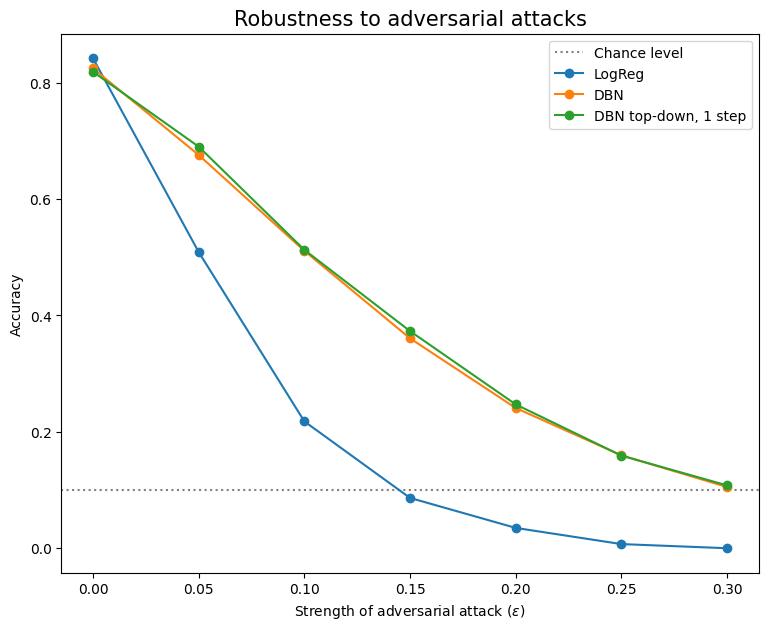

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(9, 7), sharey=True)

__ = ax.axhline(0.1, color='gray', linestyle=':')
__ = ax.plot(epsilon_values, accuracies_logreg,marker="o")
__ = ax.plot(epsilon_values, accuracies_dbn_0,marker="o")
__ = ax.plot(epsilon_values, accuracies_dbn_1,marker="o")
__ = ax.set_xlabel("Strength of adversarial attack ($\epsilon$)")
__ = ax.set_ylabel("Accuracy")
__ = ax.set_title("Robustness to adversarial attacks", {'fontsize': 15})
__ = ax.legend(["Chance level", "LogReg", "DBN", "DBN top-down, 1 step"])

To analyse the vulnerability of models to adversarial perturbations, it is applied the Fast Gradient Sign Method (FGSM) is applied with different values of $\epsilon$

The accuracy is evaluated for 3 models: logistic regression, the linear read-out on second layer of the DBN, and a variant of the DBN that includs a single step of  top-down reconstruction.

The results show that the logistic regression is strongly vulnerable to the  adversarial attack, also for small values of $\epsilon$.
The accuracy collapses rapidly until it reaches chance level. The opposite occurs for the DBN, because it remains at higher accuracy levels.
In contrast, the DBN model maintains significantly higher performance over a wide range of attack intensities, this implies greater structural robustness.

The introduction of a single step top-down recostruction improves robustness of the DBN, especially in intermediate values. This suggests that the generative mechanism of the DBN can act as a kind of denoising, reducing the effect of adversarial perturbations before classification.

Overall, these results indicate that, even if the DBN is not immune to adversarial attacks, the hierarchical representations learned in an unsupervised way are more stable than those of a purely discriminative model, and that top-down processes can help to improve robustness.
